# **Task 1: Data Loading and Initial Inspection**

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
# 1.1 Load Titanic dataset from seaborn or URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)


In [94]:
# 1.2 Displays first 5 rows
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
# 1.3 Checking the datatypes
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
# 1.4 Descriptive statistics
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [97]:
# 1.5 Total number of missing values for each column
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Task 2: Handling Missing Values**

In [98]:
# 2.1 Percentage of missing values in Cabin
missing_cabin = titanic['Cabin'].isnull().mean() * 100
print(f"Missing Cabin values: {missing_cabin:.2f}%")


Missing Cabin values: 77.10%


Decision: We need to drop the cabin column entirely.Because,It contains more than 75% missing  values which would lead to errors.

In [99]:
# 2.2 Finding the most frequent port (mode)
embarked_mode = titanic['Embarked'].mode()[0]
print("Most frequent Embarked value:", embarked_mode)

# 2.2 Filling in missing values with mode
titanic['Embarked'].fillna(embarked_mode, inplace=True)

Most frequent Embarked value: S


/tmp/ipython-input-4263213540.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Embarked'].fillna(embarked_mode, inplace=True)


In [100]:
# 3. Filling missing age values with median
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


/tmp/ipython-input-1590838778.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


# **Task 3: Univariate Analysis**

Overall Survival Rate: 38.38%


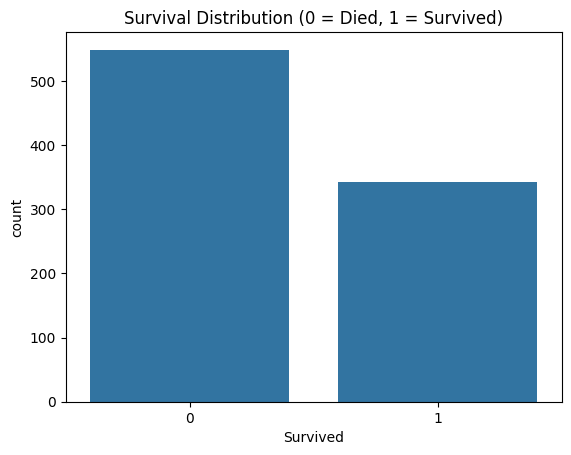

In [101]:
# 3.1 Calculating survival rate
survival_rate = titanic['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

# 3.1 Visualization
sns.countplot(x='Survived', data=titanic)
plt.title("Survival Distribution (0 = Died, 1 = Survived)")
plt.show()

/tmp/ipython-input-900399529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=titanic, palette='Set2')


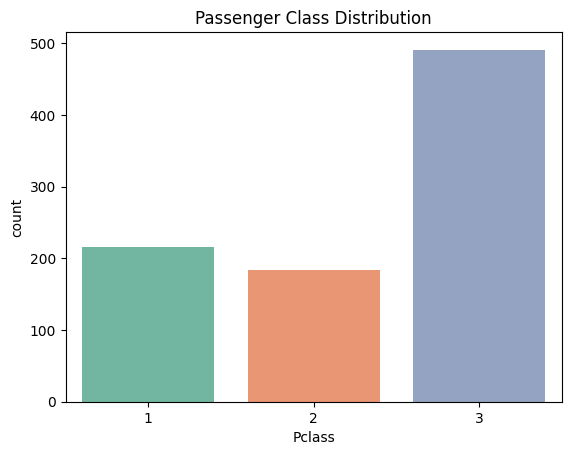

Most passengers were in class: 3


In [102]:
# 3.2 Passenger class distribution
sns.countplot(x='Pclass', data=titanic, palette='Set2')
plt.title("Passenger Class Distribution")
plt.show()

print("Most passengers were in class:", titanic['Pclass'].mode()[0])


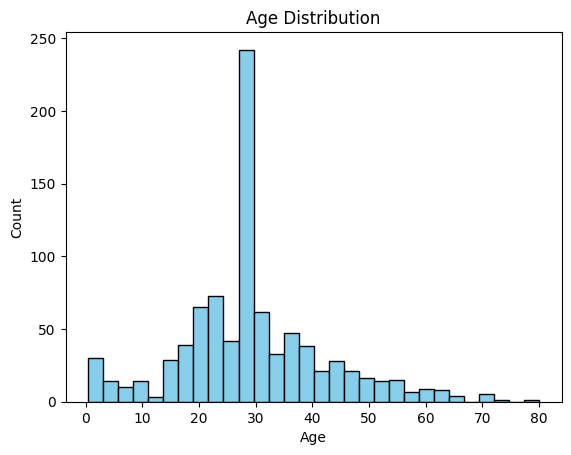

In [103]:
# 3.3 Age distribution
plt.hist(titanic['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# **Task 4: Bivariate and Multivariate Analysis**

Survived    0    1
Sex               
female     81  233
male      468  109


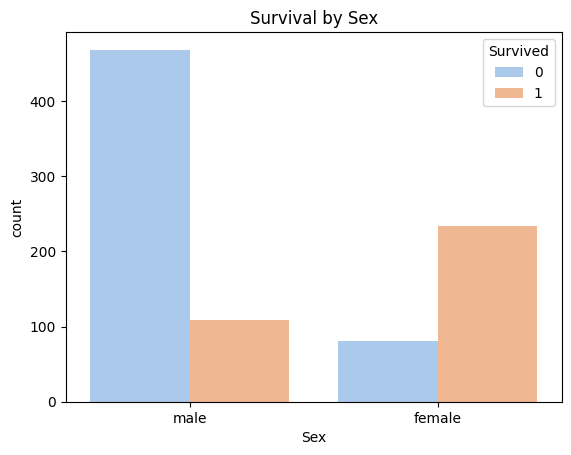

In [104]:
# 4.1 Survival by sex
# Crosstab
sex_survival = pd.crosstab(titanic['Sex'], titanic['Survived'])
print(sex_survival)

# Visualization
sns.countplot(x='Sex', hue='Survived', data=titanic, palette='pastel')
plt.title("Survival by Sex")
plt.show()


Question: Which gender had a significantly higher survival rate?

Ans: Females had a significantly higher survival rate than males.

/tmp/ipython-input-294813384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic, palette='Blues')


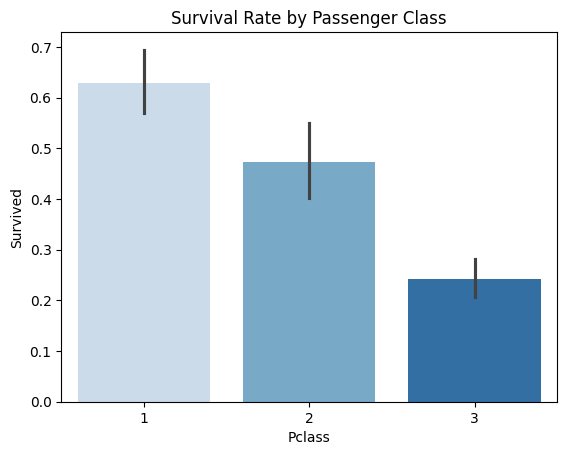

In [105]:
# 4.2 Survival by class
sns.barplot(x='Pclass', y='Survived', data=titanic, palette='Blues')
plt.title("Survival Rate by Passenger Class")
plt.show()


Question: Is there a clear correlation between ticket class and survival probability?

Ans: There is a strong negative correlation between ticket class and survival probability. Passengers in higher classes had much better chances of survival than those in lower classes.

/tmp/ipython-input-1141793311.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(titanic[titanic['Survived'] == 1]['Age'], label='Survived', shade=True)
/tmp/ipython-input-1141793311.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(titanic[titanic['Survived'] == 0]['Age'], label='Died', shade=True)


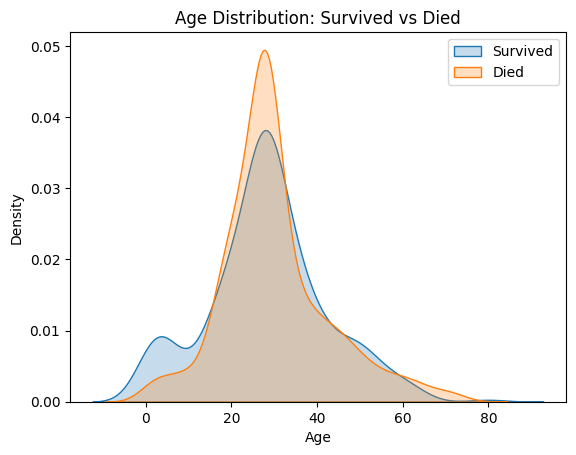

In [106]:
# 4.3 Survival by age
# Compare age distributions
sns.kdeplot(titanic[titanic['Survived'] == 1]['Age'], label='Survived', shade=True)
sns.kdeplot(titanic[titanic['Survived'] == 0]['Age'], label='Died', shade=True)
plt.title("Age Distribution: Survived vs Died")
plt.xlabel("Age")
plt.legend()
plt.show()


Observation: What does the plot suggest about the survival chances of children and the elderly?

Ans: The plot suggests that children had a higher chance of survival compared to adults and the elderly.Older passengers had a much lower survival rate.

/tmp/ipython-input-2410826394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=titanic, palette='Blues')


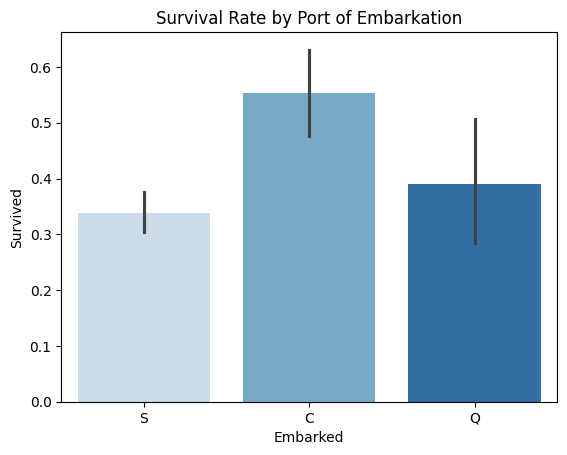

In [107]:
# 4.4 Survival by embarked
sns.barplot(x='Embarked', y='Survived', data=titanic, palette='Blues')
plt.title("Survival Rate by Port of Embarkation")
plt.show()


Passengers from Cherbourg (C) had the highest survival rates.

# **Task 5: Conclusion and Insights**

Based on my EDA, it is evident that gender, passenger class and age significantly impacted the chances of survival on Titanic.
"Women & children first" policy might have contributed to this, as well as socioeconomic factors.
Overall, sex, pclass and age are the most significant predictors for survivor rates in this dataset.